In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Set aesthetics for academic publications
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 14,
    'font.family': 'sans-serif'
})

In [15]:
df_raw = pd.read_csv('evaluations_full_metrics.csv')
df_raw.head(2)

,Evaluation ID,Created At,Query,Model A,Model B,A_Step1_Embedding,A_Step2_Shortlist,A_Step3_Rerank,A_Step4_FetchDB,A_Step5_Aggregate,...,B_Step3_Rerank,B_Step4_FetchDB,B_Step5_Aggregate,B_Step6_Format,B_Total,Results Identical,Evaluator Type,Preference Submitted,Winner,Reasoning
0,1082,2026-05-29 09:29:37.745011+00:00,I need a specialist in maternal-fetal medicine...,512_dim,768_dim,0.075343,0.222100,0.004024,0.012717,0.000588,...,0.0,0.011409,0.000587,0.00014,0.305685,False,llm,True,512_dim,List A is superior because it contains experts...
1,1081,2026-05-29 09:29:06.771847+00:00,I need a specialist in maternal-fetal medicine...,256_dim,768_dim,0.075343,0.181112,0.004655,0.015405,0.000569,...,0.0,0.011409,0.000587,0.00014,0.305685,False,llm,True,256_dim,List A is superior because it includes Robert ...


In [16]:
df_llm = df_raw[(df_raw['Evaluator Type'] == 'llm') & (df_raw['Preference Submitted'] == True)].copy()
print(f"Using {len(df_llm)} LLM evaluation records.")

Using 1000 LLM evaluation records.


In [17]:
# Extract isolated runs for Model A
df_a = df_llm[['Query', 'Model A', 'A_Step2_Shortlist', 'A_Step3_Rerank']].copy()
df_a.columns = ['Query', 'Dimension', 'Step2_Shortlist', 'Step3_Rerank']

# Extract isolated runs for Model B
df_b = df_llm[['Query', 'Model B', 'B_Step2_Shortlist', 'B_Step3_Rerank']].copy()
df_b.columns = ['Query', 'Dimension', 'Step2_Shortlist', 'Step3_Rerank']

# Combine datasets and calculate total Vector Latency (Shortlisting + Reranking)
df_combined = pd.concat([df_a, df_b], ignore_index=True)
df_combined['Vector_Latency'] = df_combined['Step2_Shortlist'] + df_combined['Step3_Rerank']

# Parse numerical dimensions
df_combined['Dim_Num'] = df_combined['Dimension'].apply(lambda x: int(str(x).split('_')[0]))

# Deduplicate to maintain exactly one record per unique Query and Dimension
df_latency = df_combined.drop_duplicates(subset=['Query', 'Dim_Num']).copy()

print(f"Deduplicated observations: {len(df_latency)} (Expected: 500 for 100 queries x 5 dimensions)")
print(df_latency.groupby('Dim_Num')['Vector_Latency'].describe())

Deduplicated observations: 500 (Expected: 500 for 100 queries x 5 dimensions)
         count      mean       std       min       25%       50%       75%  \
Dim_Num                                                                      
64       100.0  0.163577  0.129657  0.041431  0.052198  0.102890  0.277829   
128      100.0  0.153968  0.130614  0.023386  0.037114  0.099040  0.272588   
256      100.0  0.169676  0.121914  0.024905  0.063711  0.138703  0.263753   
512      100.0  0.192801  0.106405  0.025196  0.095265  0.180255  0.269326   
768      100.0  0.210712  0.099384  0.040855  0.130900  0.205366  0.290205   

              max  
Dim_Num            
64       0.566933  
128      0.557770  
256      0.574182  
512      0.533911  
768      0.475666  


## How does vector truncation affect latency, and is the speedup statistically significant?

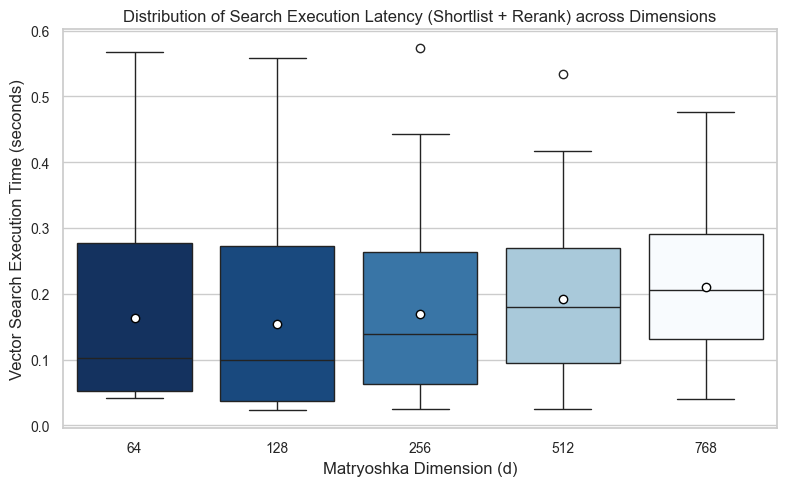

In [18]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df_latency, 
    x='Dim_Num', 
    y='Vector_Latency', 
    palette="Blues_r",
    hue="Dim_Num",
    legend=False,
    showmeans=True,
    meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"6"}
)
plt.title('Distribution of Search Execution Latency (Shortlist + Rerank) across Dimensions')
plt.xlabel('Matryoshka Dimension (d)')
plt.ylabel('Vector Search Execution Time (seconds)')
plt.tight_layout()
plt.savefig('mrl_latency_boxplot.png', dpi=300)
plt.show()

In [19]:
# Perform Shapiro-Wilk test for normality on residuals
grouped_data = [group['Vector_Latency'].values for name, group in df_latency.groupby('Dim_Num')]
f_stat, p_val_anova = stats.f_oneway(*grouped_data)

print(f"One-way ANOVA F-Statistic: {f_stat:.4f}")
print(f"One-way ANOVA p-value: {p_val_anova:.4e}")

if p_val_anova < 0.05:
    print("Result: Highly significant. Reject the null hypothesis. Proceeding to post-hoc analysis...")
else:
    print("Result: No significant difference detected.")

One-way ANOVA F-Statistic: 3.8320
One-way ANOVA p-value: 4.4472e-03
Result: Highly significant. Reject the null hypothesis. Proceeding to post-hoc analysis...


In [20]:
# Pairwise Tukey's HSD test
tukey = pairwise_tukeyhsd(
    endog=df_latency['Vector_Latency'],
    groups=df_latency['Dim_Num'],
    alpha=0.05
)
print(tukey.summary())

Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
    64    128  -0.0096 0.9787 -0.0554 0.0362  False
    64    256   0.0061 0.9962 -0.0397 0.0519  False
    64    512   0.0292  0.406 -0.0166  0.075  False
    64    768   0.0471 0.0401  0.0013 0.0929   True
   128    256   0.0157 0.8815 -0.0301 0.0615  False
   128    512   0.0388 0.1397  -0.007 0.0846  False
   128    768   0.0567 0.0067   0.011 0.1025   True
   256    512   0.0231 0.6391 -0.0227 0.0689  False
   256    768    0.041 0.1032 -0.0048 0.0868  False
   512    768   0.0179 0.8214 -0.0279 0.0637  False
---------------------------------------------------


## Quality Analysis

In [21]:
def compute_elo(matches, K=32, init_elo=1000.0):
    """
    Computes ELO ratings from a series of pairwise matchups.
    """
    dimensions = ['64_dim', '128_dim', '256_dim', '512_dim', '768_dim']
    elos = {dim: init_elo for dim in dimensions}
    
    for _, row in matches.iterrows():
        m_a = row['Model A']
        m_b = row['Model B']
        winner = row['Winner']
        
        # Set actual scores
        if winner == m_a:
            S_a, S_b = 1.0, 0.0
        elif winner == m_b:
            S_a, S_b = 0.0, 1.0
        else: # Draw
            S_a, S_b = 0.5, 0.5
            
        r_a, r_b = elos[m_a], elos[m_b]
        
        # Expected scores
        E_a = 1.0 / (1.0 + 10.0 ** ((r_b - r_a) / 400.0))
        E_b = 1.0 / (1.0 + 10.0 ** ((r_a - r_b) / 400.0))
        
        # ELO updates
        elos[m_a] = r_a + K * (S_a - E_a)
        elos[m_b] = r_b + K * (S_b - E_b)
        
    return elos

### Bootstrapping Tournament matches (Monte Carlo)
To eliminate bias introduced by sequence order and output standard errors for ELO.

In [23]:
n_iterations = 1000
bootstrap_elos = []

for i in range(n_iterations):
    # Sample matches randomly with replacement
    df_sampled = df_llm.sample(frac=1.0, replace=True, random_state=727 + i)
    elos = compute_elo(df_sampled)
    bootstrap_elos.append(elos)

In [24]:
df_boot = pd.DataFrame(bootstrap_elos)
df_boot_summary = pd.DataFrame({
    'Mean_ELO': df_boot.mean(),
    'Std_Error': df_boot.std(),
    'CI_Lower': df_boot.quantile(0.025),
    'CI_Upper': df_boot.quantile(0.975)
}).sort_values('Mean_ELO', ascending=False)

# Parse numerical values for regression/correlation
df_boot_summary['Dim_Num'] = [int(idx.split('_')[0]) for idx in df_boot_summary.index]
df_boot_summary = df_boot_summary.sort_values('Dim_Num')

print("Bootstrapped ELO Rating Results (95% Confidence Interval):")
print(df_boot_summary)

Bootstrapped ELO Rating Results (95% Confidence Interval):
            Mean_ELO  Std_Error     CI_Lower     CI_Upper  Dim_Num
64_dim    925.579364  48.082823   830.256946  1017.656134       64
128_dim  1041.929362  46.198457   959.132229  1135.644740      128
256_dim  1089.044279  45.372861   998.721767  1175.416543      256
512_dim  1112.541461  45.204702  1013.985825  1192.979850      512
768_dim   830.905534  46.342317   737.794218   921.136121      768


Saved ELO chart to 'mrl_quality_elo_bar.png'.


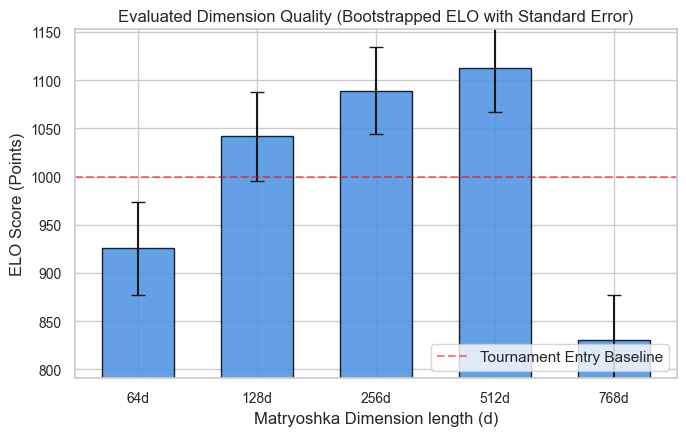

In [26]:
plt.figure(figsize=(7, 4.5))
plt.bar(
    x=[f"{dim}d" for dim in df_boot_summary['Dim_Num']],
    height=df_boot_summary['Mean_ELO'],
    yerr=df_boot_summary['Std_Error'],
    color='#4a90e2',
    edgecolor='black',
    capsize=5,
    alpha=0.85,
    width=0.6
)
plt.axhline(1000, color='red', linestyle='--', alpha=0.5, label='Tournament Entry Baseline')
plt.title('Evaluated Dimension Quality (Bootstrapped ELO with Standard Error)', fontsize=12)
plt.xlabel('Matryoshka Dimension length (d)')
plt.ylabel('ELO Score (Points)')
plt.ylim(df_boot_summary['Mean_ELO'].min() - 40, df_boot_summary['Mean_ELO'].max() + 40)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('mrl_quality_elo_bar.png')
print("Saved ELO chart to 'mrl_quality_elo_bar.png'.")

In [27]:
corr_coef, corr_p = stats.spearmanr(df_boot_summary['Dim_Num'], df_boot_summary['Mean_ELO'])
print(f"Spearman's Rank Correlation (Dim_Num vs Mean_ELO): {corr_coef:.6f}")
print(f"Spearman's p-value: {corr_p:.6f}")

Spearman's Rank Correlation (Dim_Num vs Mean_ELO): 0.000000
Spearman's p-value: 1.000000


## The Pareto Efficiency Frontier (Trade-Off Optimization)
Merging ELO scores and execution latency averages to find the optimal deployment model.

In [29]:
# Calculate deterministic mean latencies
mean_latency = df_latency.groupby('Dim_Num')['Vector_Latency'].mean().reset_index()
df_pareto = pd.merge(df_boot_summary, mean_latency, on='Dim_Num')

print("\nPareto Frontier Coordinates:")
for _, row in df_pareto.iterrows():
    print(f"Dimension: {int(row['Dim_Num']):>3} | Latency: {row['Vector_Latency']:.5f}s | ELO: {row['Mean_ELO']:.2f}")


Pareto Frontier Coordinates:
Dimension:  64 | Latency: 0.16358s | ELO: 925.58
Dimension: 128 | Latency: 0.15397s | ELO: 1041.93
Dimension: 256 | Latency: 0.16968s | ELO: 1089.04
Dimension: 512 | Latency: 0.19280s | ELO: 1112.54
Dimension: 768 | Latency: 0.21071s | ELO: 830.91


Saved Pareto Frontier to 'mrl_pareto_frontier.png'.


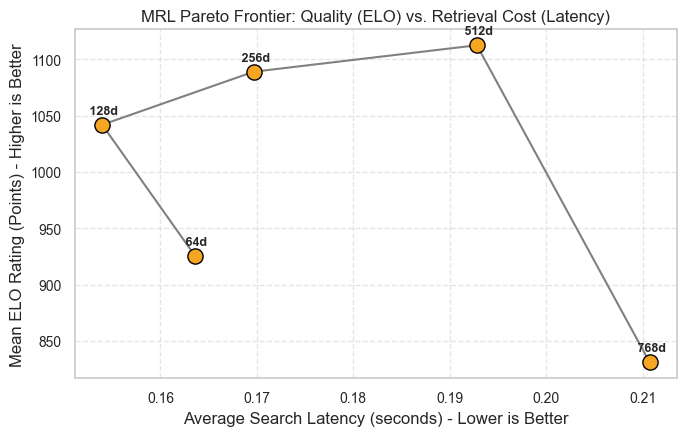

In [31]:
plt.figure(figsize=(7, 4.5))
plt.scatter(
    df_pareto['Vector_Latency'], 
    df_pareto['Mean_ELO'], 
    color='#f5a623', 
    s=120, 
    edgecolor='black',
    zorder=3
)
plt.plot(
    df_pareto['Vector_Latency'], 
    df_pareto['Mean_ELO'], 
    color='grey', 
    linestyle='-', 
    linewidth=1.5,
    zorder=2
)

# Label data points
for _, row in df_pareto.iterrows():
    plt.annotate(
        f" {int(row['Dim_Num'])}d", 
        (row['Vector_Latency'], row['Mean_ELO']),
        textcoords="offset points", 
        xytext=(0, 8), 
        ha='center',
        fontsize=9,
        fontweight='bold'
    )

plt.title('MRL Pareto Frontier: Quality (ELO) vs. Retrieval Cost (Latency)', fontsize=12)
plt.xlabel('Average Search Latency (seconds) - Lower is Better')
plt.ylabel('Mean ELO Rating (Points) - Higher is Better')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig('mrl_pareto_frontier.png')
print("Saved Pareto Frontier to 'mrl_pareto_frontier.png'.")